# COVID-19 Global Statistics — Exploratory Data Analysis

**A learn-by-doing EDA project.**

Think of this notebook as a lab notebook, not a polished report — every step explains *why* we're doing it, not just *how*, so you can reuse this exact structure on your next dataset. That's the real skill: the workflow, not this one dataset.

Run each cell top to bottom in Colab or VS Code. Read the markdown before each code cell — that's where the teaching happens.

## 1. Project Overview

**What is this?**
A country-level snapshot of the COVID-19 pandemic — one row per country, with cumulative case counts, deaths, recoveries, testing volume, and population, as of the dataset's snapshot date.

**Objective / research question:**
> How did COVID-19's impact (cases, deaths, testing capacity) vary across countries and continents, and what factors seem related to how hard a country was hit?

**Expected outcomes:**
- A clean, analysis-ready version of this dataset
- Summary stats and visuals showing how cases/deaths/testing differ by continent
- A short list of concrete, data-backed insights (not just "here are 10 charts")

**Why this matters as a learning project:** this is the same 5-step skeleton (Overview → Description → Understanding → Cleaning → EDA)

## 2. Dataset Description

Before touching any code, always answer these questions about a new dataset:
- **Source?** Country-level COVID-19 statistics (Kaggle-style aggregate; matches the classic "Worldometer COVID-19" export format).
- **Grain?** One row = one country.
- **Target variable?** None built-in — this isn't a labeled ML dataset, it's for analysis/exploration. If you *were* to build a model later, `total_deaths` or `total_deaths_per_1m_population` would be natural targets.

Let's load it and get the facts programmatically instead of eyeballing the CSV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('./raw dataset/dataset.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 226 rows x 12 columns


,country,continent,total_confirmed,total_deaths,total_recovered,active_cases,serious_or_critical,total_cases_per_1m_population,total_deaths_per_1m_population,total_tests,total_tests_per_1m_population,population
0,Afghanistan,Asia,179267,7690.0,162202.0,9375.0,1124.0,4420,190.0,951337.0,23455.0,40560636
1,Albania,Europe,275574,3497.0,271826.0,251.0,2.0,95954,1218.0,1817530.0,632857.0,2871945
2,Algeria,Africa,265816,6875.0,178371.0,80570.0,6.0,5865,152.0,230861.0,5093.0,45325517
3,Andorra,Europe,42156,153.0,41021.0,982.0,14.0,543983,1974.0,249838.0,3223924.0,77495
4,Angola,Africa,99194,1900.0,97149.0,145.0,NaN,2853,55.0,1499795.0,43136.0,34769277


**Column meanings** 

| Column | Meaning |
|---|---|
| `country` | Country name (identifier, not a feature for stats) |
| `continent` | Continent — our main categorical grouping variable |
| `total_confirmed` | Cumulative confirmed COVID-19 cases |
| `total_deaths` | Cumulative deaths |
| `total_recovered` | Cumulative recoveries |
| `active_cases` | Cases still active at snapshot time |
| `serious_or_critical` | Currently in serious/critical condition |
| `total_cases_per_1m_population` | Cases normalized per 1 million people (lets you compare a big country to a small one fairly) |
| `total_deaths_per_1m_population` | Deaths per 1 million people |
| `total_tests` | Cumulative tests administered |
| `total_tests_per_1m_population` | Tests per 1 million people (proxy for testing capacity/effort) |
| `population` | Country population |

Notice the `_per_1m_population` columns already exist — that's a hint the raw counts (`total_confirmed`, `total_deaths`) are **not directly comparable across countries** (India vs. Iceland). Keep that in mind for EDA — we'll mostly compare using the per-1m columns.

In [2]:
# Data types — flags anything that should be numeric but got read as text
df.dtypes

country                               str
continent                             str
total_confirmed                     int64
total_deaths                      float64
total_recovered                   float64
active_cases                      float64
serious_or_critical               float64
total_cases_per_1m_population       int64
total_deaths_per_1m_population    float64
total_tests                       float64
total_tests_per_1m_population     float64
population                          int64
dtype: object

In [3]:
#  Initial Observations
print(df.describe(include='all'))
print(df.head(5))
print(df.tail(5))
print(df.sample(5, random_state=42))
print(df.columns)
print(df.info())
print("Null values",df.isnull().sum())
print(df.duplicated().sum())

            country continent  total_confirmed  total_deaths  total_recovered  \
count           226       226     2.260000e+02  2.180000e+02     2.040000e+02   
unique          226         6              NaN           NaN              NaN   
top     Afghanistan    Africa              NaN           NaN              NaN   
freq              1        58              NaN           NaN              NaN   
mean            NaN       NaN     2.305651e+06  2.884442e+04     2.256851e+06   
std             NaN       NaN     7.575510e+06  9.971254e+04     7.613357e+06   
min             NaN       NaN     2.000000e+00  1.000000e+00     1.000000e+00   
25%             NaN       NaN     2.412600e+04  2.370000e+02     1.619300e+04   
50%             NaN       NaN     1.793750e+05  2.251500e+03     1.372740e+05   
75%             NaN       NaN     1.090902e+06  1.400650e+04     1.006245e+06   
max             NaN       NaN     8.420947e+07  1.026646e+06     8.124426e+07   

        active_cases  serio

## 3. Data Understanding

Here we're hunting for problems before we clean anything. Three things to always check: **missing values, duplicates, and inconsistencies** (weird types, impossible values, mismatched categories).

In [4]:
# Structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         226 non-null    str    
 1   continent                       226 non-null    str    
 2   total_confirmed                 226 non-null    int64  
 3   total_deaths                    218 non-null    float64
 4   total_recovered                 204 non-null    float64
 5   active_cases                    204 non-null    float64
 6   serious_or_critical             145 non-null    float64
 7   total_cases_per_1m_population   226 non-null    int64  
 8   total_deaths_per_1m_population  218 non-null    float64
 9   total_tests                     212 non-null    float64
 10  total_tests_per_1m_population   212 non-null    float64
 11  population                      226 non-null    int64  
dtypes: float64(7), int64(3), str(2)
memory usage: 2

In [5]:
# Summary statistics — numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_confirmed,226.0,2.305651e+06,7.575510e+06,2.0,24126.00,179375.0,1090902.00,8.420947e+07
total_deaths,218.0,2.884442e+04,9.971254e+04,1.0,237.00,2251.5,14006.50,1.026646e+06
total_recovered,204.0,2.256851e+06,7.613357e+06,1.0,16193.00,137274.0,1006244.75,8.124426e+07
active_cases,204.0,6.861029e+04,2.350430e+05,0.0,239.75,1634.0,19296.75,1.938567e+06
serious_or_critical,145.0,2.694828e+02,8.831747e+02,1.0,5.00,17.0,139.00,8.318000e+03
total_cases_per_1m_population,226.0,1.481568e+05,1.552029e+05,16.0,11748.25,98271.5,255632.75,7.043020e+05
total_deaths_per_1m_population,218.0,1.157550e+03,1.212834e+03,2.0,172.50,768.0,1850.00,6.297000e+03
total_tests,212.0,2.987445e+07,1.079635e+08,5117.0,347296.75,2238917.5,12338623.50,1.016883e+09
total_tests_per_1m_population,212.0,1.944650e+06,3.318400e+06,5093.0,166726.00,775335.5,2267408.25,2.184247e+07
population,226.0,3.495521e+07,1.390338e+08,805.0,560512.50,5800569.5,21872837.75,1.439324e+09


Reading a `.describe()` table: look at **min vs max vs mean**. If `mean` is way closer to `min` than `max`, that's a right-skewed distribution (a few huge countries dragging the average up) — very common with population-scale data like this. We'll confirm this visually in the EDA section.

In [6]:
# Missing values — count and percentage
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
serious_or_critical,81,35.8
active_cases,22,9.7
total_recovered,22,9.7
total_tests_per_1m_population,14,6.2
total_tests,14,6.2
total_deaths,8,3.5
total_deaths_per_1m_population,8,3.5


In [7]:
# Duplicate rows, and duplicate countries specifically (more meaningful than a full-row duplicate check)
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate country names:", df['country'].duplicated().sum())

Fully duplicated rows: 0
Duplicate country names: 0


In [8]:
# Consistency checks — values that shouldn't logically happen
print("Negative values in numeric columns:")
num_cols = df.select_dtypes(include=np.number).columns
print((df[num_cols] < 0).sum()[lambda x: x > 0])

print("\nRecovered + Active > Confirmed (would be impossible):")
check = df['total_recovered'].fillna(0) + df['active_cases'].fillna(0) > df['total_confirmed'] * 1.05  # 5% slack for reporting lag
print(check.sum(), "rows flagged")

Negative values in numeric columns:
Series([], dtype: int64)

Recovered + Active > Confirmed (would be impossible):
0 rows flagged


**What we typically find in this dataset, and why it happens:**
- `serious_or_critical` has the most missing values (~36%) — many countries simply didn't report ICU-level breakdowns.
- `total_recovered` / `active_cases` missing together (~10%) — some countries stopped tracking "active" once recovery tracking became unreliable.
- `total_tests` missing (~6%) — smaller/lower-resource countries often had incomplete testing infrastructure, so it's not random — it's related to the country itself. That matters for how we handle it (more below).

This is the key EDA mindset: missingness isn't just a number to patch, it's a clue about *why* the data is shaped the way it is.

## 4. Data Cleaning

**Rule of thumb:** don't clean on autopilot. For every missing value or outlier, ask "why is this missing/extreme, and what does that imply for how I should handle it?"

Here's the plan and reasoning for *this* dataset:

| Issue | Technique | Why |
|---|---|---|
| `serious_or_critical` missing (~36%) | Keep NaN, don't impute | Too much missing to safely guess; filling with 0 would falsely imply "no critical cases" for countries that just didn't report. We'll exclude it from analyses that need complete data, not fake a number. |
| `total_recovered`, `active_cases` missing (~10%) | Impute with 0 *only if* `total_confirmed` is also very low, else leave NaN | Missing here usually means "stopped tracking," not "zero" |
| `total_tests`, `total_tests_per_1m_population` missing (~6%) | Leave as NaN | Same logic — imputing testing volume would be fabricating data |
| `total_deaths` missing (~4%) | Leave as NaN, note in analysis | Small enough to just exclude from death-focused stats via `.dropna()` per-analysis rather than deleting whole rows |
| Duplicates | Drop if any found | Duplicates would double-count a country |

**Why we're *not* mass-imputing with mean/median here:** that technique makes sense when data is "missing at random." Here it isn't — missingness correlates with a country's reporting capacity, which is itself an interesting variable. Silently filling it in would hide that signal, not clean it.

In [9]:
df_clean = df.copy()

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - len(df_clean)} duplicate rows")

# Standardize text columns
df_clean['country'] = df_clean['country'].str.strip()
df_clean['continent'] = df_clean['continent'].str.strip()

print(df_clean['continent'].unique())

Dropped 0 duplicate rows
<StringArray>
[             'Asia',            'Europe',            'Africa',
     'North America',     'South America', 'Australia/Oceania']
Length: 6, dtype: str


In [10]:
# Missing values
df_clean.isnull().sum()

country                            0
continent                          0
total_confirmed                    0
total_deaths                       8
total_recovered                   22
active_cases                      22
serious_or_critical               81
total_cases_per_1m_population      0
total_deaths_per_1m_population     8
total_tests                       14
total_tests_per_1m_population     14
population                         0
dtype: int64

## 5. Exploratory Data Analysis

We'll go in the standard order: **univariate → bivariate → multivariate**. Each level adds one more variable into the picture — univariate asks "what does one column look like on its own?", bivariate asks "how do two columns move together?", multivariate asks "what's the whole system doing at once?".

### 5.1 Univariate Analysis

Start with the shape of single variables. Histograms show the *distribution* (where most values cluster); bar charts show *counts by category*.

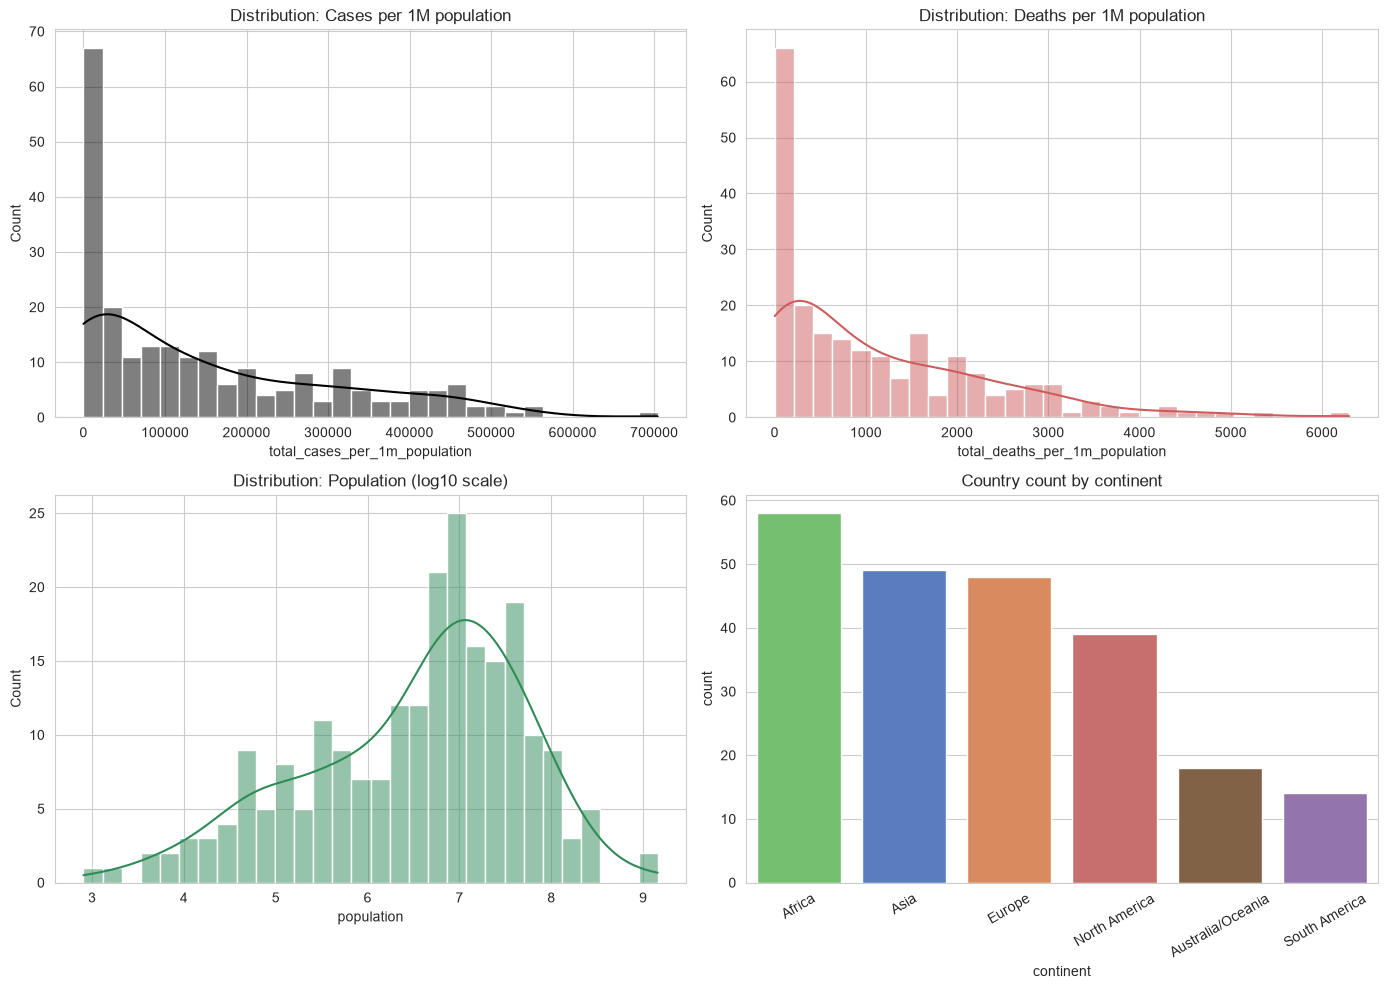

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_clean['total_cases_per_1m_population'], bins=30, kde=True, ax=axes[0,0], color='black')
axes[0,0].set_title('Distribution: Cases per 1M population')

sns.histplot(df_clean['total_deaths_per_1m_population'].dropna(), bins=30, kde=True, ax=axes[0,1], color='indianred')
axes[0,1].set_title('Distribution: Deaths per 1M population')

sns.histplot(np.log10(df_clean['population']), bins=30, kde=True, ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Distribution: Population (log10 scale)')

sns.countplot(data=df_clean, x='continent', hue='continent', order=df_clean['continent'].value_counts().index, ax=axes[1,1], palette='muted')
axes[1,1].set_title('Country count by continent')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Why `population` is plotted on a log scale:** population spans from ~1,000 (tiny island nations) to ~1.4 billion (India/China). On a normal scale, the histogram would just be one tall bar near zero and nothing else visible — log scale compresses that range so you can actually see the shape. This trick applies to almost any "money" or "population"-style column (income, revenue, city size) — they're almost always right-skewed.

### 5.2 Bivariate Analysis

Now we look at *pairs* of variables. Scatter plots for two numeric variables, box/violin plots for numeric-vs-category, crosstabs for category-vs-category.

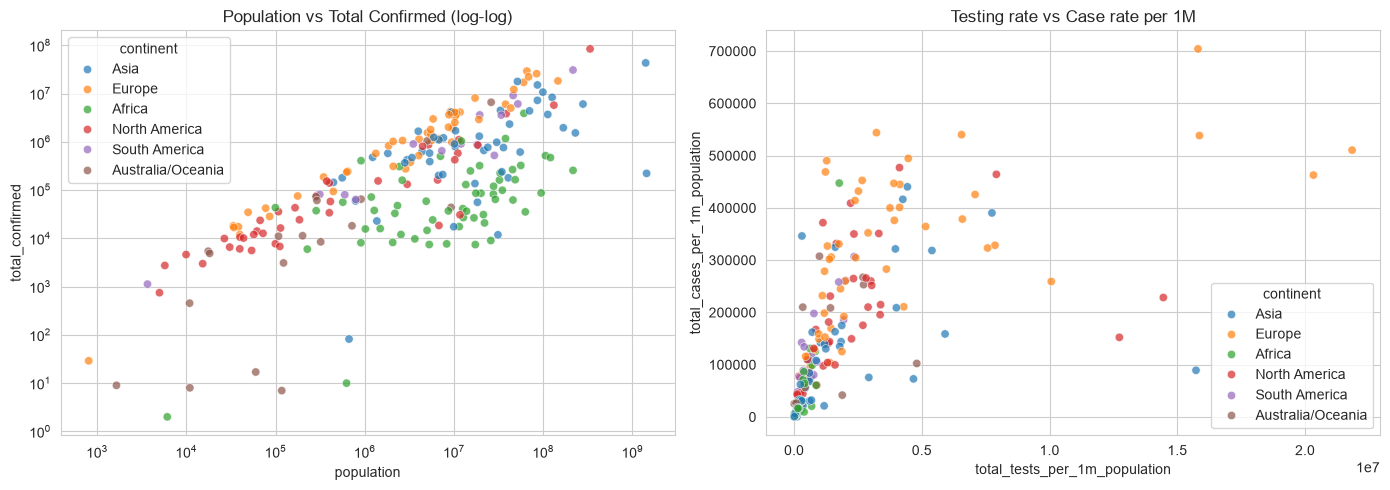

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df_clean, x='population', y='total_confirmed', hue='continent', ax=ax[0], alpha=0.7)
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].set_title('Population vs Total Confirmed (log-log)')

sns.scatterplot(data=df_clean, x='total_tests_per_1m_population', y='total_cases_per_1m_population', hue='continent', ax=ax[1], alpha=0.7)
ax[1].set_title('Testing rate vs Case rate per 1M')

plt.tight_layout()
plt.show()

**Reading the log-log scatter:** when both axes are logged and points roughly follow a straight line, that's a sign of a proportional relationship (bigger population → proportionally more cases) rather than a flat or random relationship. Log-log is the standard trick whenever you're comparing quantities that span several orders of magnitude — you'll use this constantly.

**Testing rate vs. case rate is a classic "detection bias" plot:** countries that test more per capita often *appear* to have higher case rates — not necessarily because more people got infected, but because more infections were actually caught. Worth calling out explicitly rather than assuming "more cases = worse outbreak."​

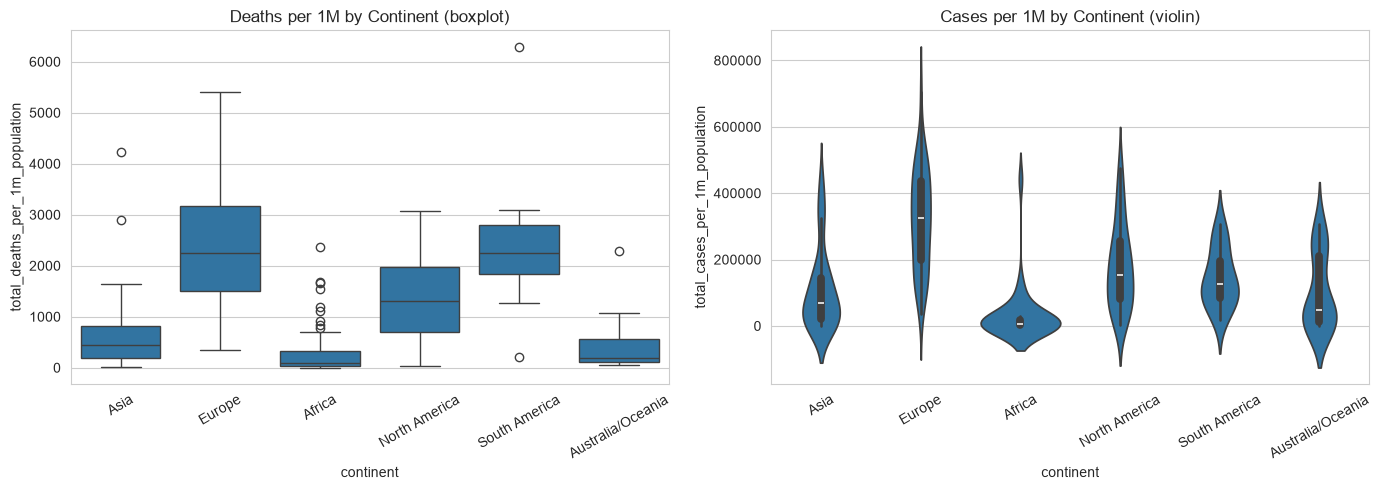

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x='continent', y='total_deaths_per_1m_population', ax=ax[0])
ax[0].set_title('Deaths per 1M by Continent (boxplot)')
ax[0].tick_params(axis='x', rotation=30)

sns.violinplot(data=df_clean, x='continent', y='total_cases_per_1m_population', ax=ax[1])
ax[1].set_title('Cases per 1M by Continent (violin)')
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Boxplot vs. violin — what's the difference?** A boxplot gives you the 5-number summary (min, Q1, median, Q3, max) and flags outliers as dots beyond the whiskers. A violin plot adds the full distribution shape (like a sideways histogram mirrored on both sides) — so you can see if a continent has one big cluster or two separate humps (bimodal), which a boxplot would hide.

**Crosstab example** — categorical vs. categorical, e.g. "how many countries per continent fall into low/medium/high case-rate buckets":

In [14]:
df_clean['case_rate_tier'] = pd.qcut(df_clean['total_cases_per_1m_population'], q=3, labels=['Low', 'Medium', 'High'])
pd.crosstab(df_clean['continent'], df_clean['case_rate_tier'])

case_rate_tier,Low,Medium,High
continent,,,
Africa,47,9,2
Asia,17,24,8
Australia/Oceania,8,4,6
Europe,0,11,37
North America,3,19,17
South America,1,8,5


`pd.qcut` splits a numeric column into equal-sized buckets by *rank* (so exactly 1/3 of countries land in each tier) — different from `pd.cut`, which splits by equal-width numeric ranges. Use `qcut` when you want balanced groups; use `cut` when the actual value boundaries matter (e.g., "under 18", "18-64", "65+").

### 5.3 Multivariate Analysis

Now all numeric variables at once — correlation matrix and pairplot to spot which variables move together across the *whole* system, not just pairwise.

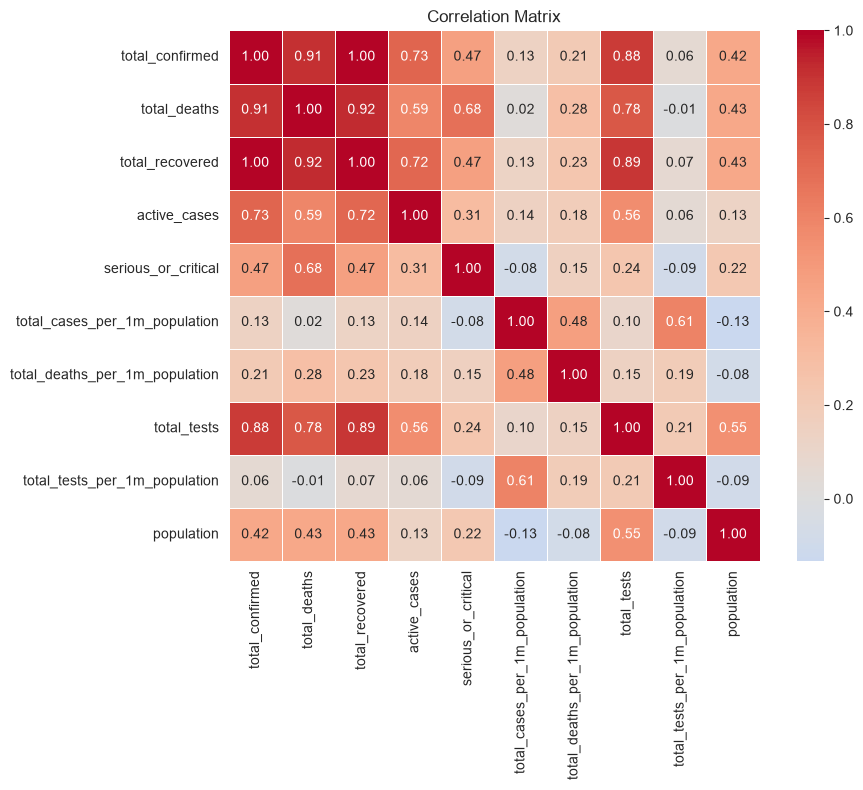

In [15]:
num_cols_corr = ['total_confirmed', 'total_deaths', 'total_recovered', 'active_cases','serious_or_critical', 'total_cases_per_1m_population','total_deaths_per_1m_population', 'total_tests', 'total_tests_per_1m_population','population']

corr = df_clean[num_cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

**Reading a correlation heatmap:** values range -1 to +1. Near +1 = move together strongly; near -1 = move opposite; near 0 = no linear relationship. Two things to watch for:
- `total_confirmed`, `total_deaths`, `total_recovered`, `population` will likely all correlate strongly — that's expected, they're all "bigger country → bigger raw numbers." This is why we compare the `_per_1m` columns instead when we want a *fair* comparison, not raw scale.
- Correlation ≠ causation — always say "moves together with" not "causes," especially with aggregate country data like this.

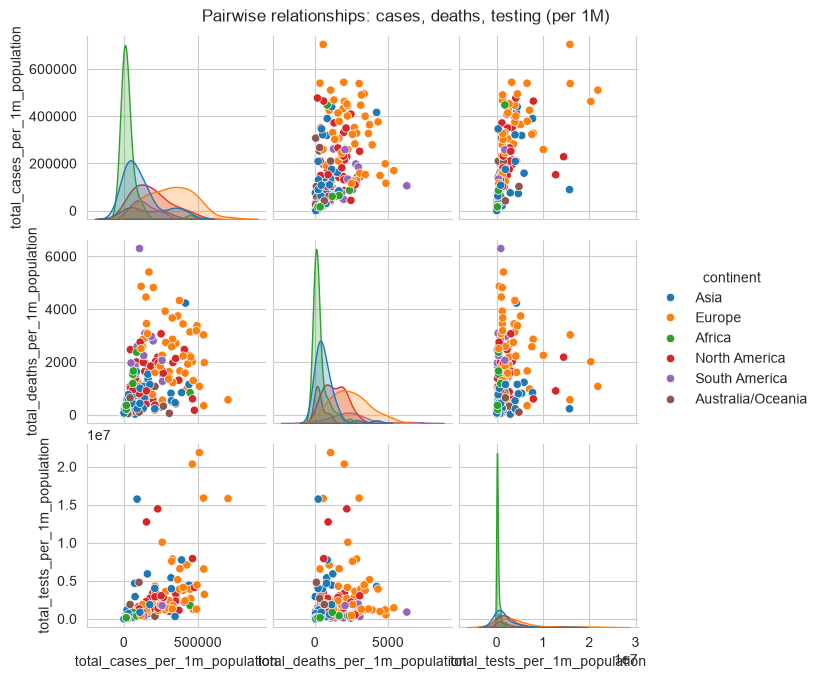

In [16]:

subset_cols = ['total_cases_per_1m_population', 'total_deaths_per_1m_population','total_tests_per_1m_population', 'continent']
sns.pairplot(df_clean[subset_cols].dropna(), hue='continent', diag_kind='kde', height=2.2)
plt.suptitle('Pairwise relationships: cases, deaths, testing (per 1M)', y=1.02)
plt.show()

A pairplot is basically "run every 2-variable scatter plot at once, plus histograms on the diagonal." It's a fast way to scan for patterns before deciding which specific pairs deserve a closer, cleaner plot like the ones above.

## Key Insights Summary

Fill this in with the specific numbers *your* run produces — but structurally, look for:

1. **Scale distortion:** raw counts (`total_confirmed`, `total_deaths`) are dominated by population size, not by how "bad" the outbreak was — the per-1M columns tell the real story.
2. **Reporting gaps aren't random:** missingness clusters in `serious_or_critical` and `total_tests`, and tends to affect countries with less testing infrastructure — meaning the countries most likely to be undercounted are also the ones most likely to have missing rows. Worth flagging as a limitation, not silently patching over.
3. **Continent-level spread:** the boxplot/violin plots should show which continents had both a high *median* case rate and wide variance (some countries doing far worse than their neighbors) vs. continents that were more uniform.
4. **Testing vs. case rate relationship:** a positive relationship here is partly a detection-bias artifact, not purely an outbreak-severity signal — a good example of "the data reflects how it was measured, not just what happened."
